In [3]:
import sys
from pathlib import Path

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation

/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/cpenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from pathlib import Path

RUNS_ROOT = Path("../inference/clipseg_cloudsen12plus_fft_low_data/masks").resolve()

OUT_ROOT = Path("../inference/clipseg_cloudsen12plus_fft_low_data").resolve()

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").resolve()

GT_KEY = "mask"
PRED_KEY = "mask"

GT_EXT = ".npz"
PRED_EXT = ".npz"

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

IGNORE_INDEX = None
STRICT = True

print("RUNS_ROOT:", RUNS_ROOT, "exists:", RUNS_ROOT.exists())
print("GT_DIR   :", GT_DIR, "exists:", GT_DIR.exists())
print("OUT_ROOT :", OUT_ROOT, "exists:", OUT_ROOT.exists())

RUNS_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data/masks exists: False
GT_DIR   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
OUT_ROOT : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data exists: True


In [8]:
import re

def pick_checkpoint(seed_dir: Path) -> Path:
    """Pick the latest checkpoint-* (by step number)."""
    ckpts = list(seed_dir.glob("checkpoint-*"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoint-* found in {seed_dir}")

    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1

    ckpts.sort(key=step)
    return ckpts[-1]


def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)

In [ ]:
def run_all_with_evaluate_segmentation():
    OUT_ROOT.mkdir(parents=True, exist_ok=True)

    pct_dirs = sorted([p for p in RUNS_ROOT.glob("pct_*") if p.is_dir()])
    if not pct_dirs:
        raise FileNotFoundError(f"No pct_* folders found under {RUNS_ROOT}")

    print(f"[INFO] Found {len(pct_dirs)} pct folders")

    for pct_dir in pct_dirs:
        out_pct_dir = OUT_ROOT / pct_dir.name
        out_pct_dir.mkdir(parents=True, exist_ok=True)

        seed_dirs = sorted([s for s in pct_dir.glob("seed_*") if s.is_dir()])
        if not seed_dirs:
            print(f"[WARN] No seed_* under {pct_dir}, skipping.")
            continue

        print(f"\n[INFO] ===== {pct_dir.name} (seeds={len(seed_dirs)}) =====")

        for seed_dir in seed_dirs:
            seed_name = seed_dir.name
            ckpt_dir = pick_checkpoint(seed_dir)
            pred_dir = ckpt_dir / "masks"

            if not pred_dir.exists():
                print(f"[WARN] Missing masks dir: {pred_dir} (skipping)")
                continue

            stage = f"{seed_name}"

            result = evaluate_segmentation(
                gt_dir=GT_DIR,
                pred_dir=pred_dir,
                model="clipseg",
                dataset="cloudsen12plus",
                stage=stage,
                num_classes=NUM_CLASSES,
                class_names=CLASS_NAMES,
                run_root=out_pct_dir,
                gt_key=GT_KEY,
                pred_key=PRED_KEY,
                gt_ext=GT_EXT,
                pred_ext=PRED_EXT,
                ignore_index=IGNORE_INDEX,
                strict=STRICT,
            )

            miou_src = Path(result["miou_csv"])
            cm_src = Path(result["cm_csv"])

            miou_dst = out_pct_dir / f"{seed_name}_miou.csv"
            cm_dst = out_pct_dir / f"{seed_name}_cm.csv"

            safe_rename(miou_src, miou_dst)
            safe_rename(cm_src, cm_dst)

            print(f"[OK] {pct_dir.name}/{seed_name} -> {miou_dst.name}, {cm_dst.name}")

    print("\n[DONE] All CSVs generated into ./inference/pct_x folders.")


In [ ]:
run_all_with_evaluate_segmentation()

In [11]:
import re
import pandas as pd
import numpy as np

In [12]:
INFER_ROOT = Path("../inference/clipseg_cloudsen12plus_fft_low_data").resolve()

OUT_CSV = Path("../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv").resolve()

PCT_MIN = 10
PCT_MAX = 90

print("INFER_ROOT:", INFER_ROOT, "exists:", INFER_ROOT.exists())

INFER_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data exists: True


In [13]:
def parse_pct_num(pct_name: str) -> int:
    m = re.match(r"pct_(\d+)$", pct_name)
    if not m:
        raise ValueError(f"Bad pct folder name: {pct_name}")
    return int(m.group(1))

def read_aggregate_row(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    if len(agg) > 1:
        raise ValueError(f"Multiple __aggregate__ rows found in {csv_path}")
    return agg.iloc[0]

def list_pct_dirs(infer_root: Path, pct_min: int, pct_max: int):
    out = []
    for d in infer_root.glob("pct_*"):
        if not d.is_dir():
            continue
        pct = parse_pct_num(d.name)
        if pct_min <= pct <= pct_max:
            out.append((pct, d))
    out.sort(key=lambda x: x[0])
    return out


In [ ]:
pct_dirs = list_pct_dirs(INFER_ROOT, PCT_MIN, PCT_MAX)
if not pct_dirs:
    raise FileNotFoundError(f"No pct folders found in {INFER_ROOT} within {PCT_MIN}-{PCT_MAX}")

seed_records = []

for pct, pct_dir in pct_dirs:
    miou_files = sorted(pct_dir.glob("seed_*_miou.csv"))
    cm_files = sorted(pct_dir.glob("seed_*_cm.csv"))

    miou_map = {f.name.replace("_miou.csv", ""): f for f in miou_files}
    cm_map   = {f.name.replace("_cm.csv", ""): f for f in cm_files}

    seeds = sorted(set(miou_map.keys()) & set(cm_map.keys()))
    if not seeds:
        print(f"[WARN] No matching seed_*_miou.csv and seed_*_cm.csv in {pct_dir}")
        continue

    for seed in seeds:
        miou_path = miou_map[seed]
        cm_path   = cm_map[seed]

        miou_agg = read_aggregate_row(miou_path)
        cm_agg   = read_aggregate_row(cm_path)

        metric_cols = [c for c in miou_agg.index if c != "id"]
        metrics = {c: float(miou_agg[c]) for c in metric_cols}

        cm_cols = [c for c in cm_agg.index if c != "id"]
        cm_counts = {c: int(cm_agg[c]) for c in cm_cols}

        seed_records.append({
            "pct": pct,
            "seed": seed,
            **metrics,
            **cm_counts,
        })

seed_df = pd.DataFrame(seed_records)
print("Per-seed table shape:", seed_df.shape)
seed_df.head(3)


Per-seed table shape: (90, 24)


,pct,seed,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow,cm_t0_p0,cm_t0_p1,...,cm_t1_p2,cm_t1_p3,cm_t2_p0,cm_t2_p1,cm_t2_p2,cm_t2_p3,cm_t3_p0,cm_t3_p1,cm_t3_p2,cm_t3_p3
0,10,seed_11,0.567922,0.824237,0.814467,0.734155,0.301745,0.421320,124701591,4735757,...,2028755,3213708,7640907,4627468,8195796,1520897,4983542,4214968,910952,14152241
1,10,seed_111,0.575284,0.826224,0.817307,0.732881,0.322745,0.428204,124579155,4933263,...,2572409,3044990,6966199,4609708,9200146,1209015,5256979,4056892,1075022,13872810
2,10,seed_22,0.572717,0.828084,0.821961,0.737495,0.302836,0.428575,125555945,4641655,...,2688449,3070414,7636797,4586033,8475567,1286671,5290431,4151722,961037,13858513


In [ ]:
all_cols = set(seed_df.columns)
metric_cols = [c for c in seed_df.columns if (c not in ["pct", "seed"]) and (not c.startswith("cm_"))]
cm_cols = [c for c in seed_df.columns if c.startswith("cm_")]

metric_mean = seed_df.groupby("pct")[metric_cols].mean().add_suffix("_mean")
metric_std  = seed_df.groupby("pct")[metric_cols].std(ddof=1).add_suffix("_std")

cm_sum = seed_df.groupby("pct")[cm_cols].sum().add_suffix("_sum")

n_seeds = seed_df.groupby("pct")["seed"].nunique().to_frame("n_seeds")

pct_df = pd.concat([n_seeds, metric_mean, metric_std, cm_sum], axis=1).reset_index()
pct_df = pct_df.sort_values("pct")

print("Per-pct summary shape:", pct_df.shape)
pct_df.head()


Per-pct summary shape: (9, 30)


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,10,10,0.571587,0.826366,0.817430,0.737429,0.309265,0.422225,0.010149,0.004451,...,23863272,30645119,74900253,45576868,86672355,12701204,53792030,41117952,10365209,137341839
1,20,10,0.609012,0.844064,0.836882,0.762559,0.377498,0.459108,0.004018,0.001349,...,21116976,32109397,59088816,41219353,106231524,13310987,47132834,35189455,10352776,149941965
2,30,10,0.626551,0.851323,0.844071,0.771651,0.415151,0.475332,0.001565,0.000985,...,22420726,31053787,50994988,37835715,118311257,12708720,45224094,33252615,10061789,154078532
3,40,10,0.633635,0.854902,0.847401,0.776275,0.427922,0.482942,0.002077,0.000685,...,22050349,29666832,49327931,37153339,121749682,11619728,45167795,32878994,10125741,154444500
4,50,10,0.639977,0.857030,0.849546,0.778642,0.440656,0.491064,0.005174,0.001888,...,22877717,30389060,45668400,36054644,126170493,11957143,43469151,31323273,9612942,158211664


In [16]:
pct_df.to_csv(OUT_CSV, index=False)
print("Wrote:", OUT_CSV)

Wrote: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv


In [17]:
import matplotlib.pyplot as plt

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

In [18]:
def pick_path(local_name: str, fallback: str) -> Path:
    p = Path(local_name)
    return p if p.exists() else Path(fallback)

LOW_DATA_CSV = pick_path("low_data_ladder.csv", "../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv")
ZS_MIOU_CSV  = pick_path("miou_clipseg_cloudsen12plus_zs_eval.csv",  "../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv")
FFT_MIOU_CSV = pick_path("miou_clipseg_cloudsen12plus_fft_eval.csv", "../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv")

low_df = pd.read_csv(LOW_DATA_CSV)
zs_df  = pd.read_csv(ZS_MIOU_CSV)
fft_df = pd.read_csv(FFT_MIOU_CSV)

print("LOW_DATA_CSV:", LOW_DATA_CSV)
print("ZS_MIOU_CSV :", ZS_MIOU_CSV)
print("FFT_MIOU_CSV:", FFT_MIOU_CSV)

display(low_df.head(3))
display(zs_df.tail(3))
display(fft_df.tail(3))


LOW_DATA_CSV: ../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv
ZS_MIOU_CSV : ../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv
FFT_MIOU_CSV: ../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,10,10,0.571587,0.826366,0.817430,0.737429,0.309265,0.422225,0.010149,0.004451,...,23863272,30645119,74900253,45576868,86672355,12701204,53792030,41117952,10365209,137341839
1,20,10,0.609012,0.844064,0.836882,0.762559,0.377498,0.459108,0.004018,0.001349,...,21116976,32109397,59088816,41219353,106231524,13310987,47132834,35189455,10352776,149941965
2,30,10,0.626551,0.851323,0.844071,0.771651,0.415151,0.475332,0.001565,0.000985,...,22420726,31053787,50994988,37835715,118311257,12708720,45224094,33252615,10061789,154078532


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
973,ROI_9795__20200617T064631_20200617T064630_T43WER,0.319882,0.568077,0.463474,0.571132,0.00000,0.244920
974,ROI_9795__20200722T064629_20200722T064811_T43WER,0.399528,0.839676,0.842845,0.523046,0.00000,0.232219
975,__aggregate__,0.255040,0.468206,0.520532,0.277302,0.08984,0.132486


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
973,ROI_9795__20200617T064631_20200617T064630_T43WER,0.789822,0.898785,0.769010,0.887427,NaN,0.713028
974,ROI_9795__20200722T064629_20200722T064811_T43WER,0.485992,0.877766,0.867751,0.689449,0.000000,0.386768
975,__aggregate__,0.657245,0.863887,0.854049,0.787455,0.470179,0.517297


In [19]:
def get_agg_row(miou_df: pd.DataFrame) -> pd.Series:
    if "id" not in miou_df.columns:
        raise ValueError("Expected 'id' column in miou CSV")
    agg = miou_df[miou_df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError("No __aggregate__ row found")
    return agg.iloc[0]

zs_agg  = get_agg_row(zs_df)
fft_agg = get_agg_row(fft_df)

print("ZS aggregate:", zs_agg.to_dict())
print("FFT aggregate:", fft_agg.to_dict())

ZS aggregate: {'id': '__aggregate__', 'miou': 0.2550400406013244, 'pixel_acc': 0.4682058520194812, 'iou_clear': 0.520532380887666, 'iou_thick_cloud': 0.277302215426787, 'iou_thin_cloud': 0.0898395431914562, 'iou_cloud_shadow': 0.1324860228993884}
FFT aggregate: {'id': '__aggregate__', 'miou': 0.6572447410809639, 'pixel_acc': 0.863886949588091, 'iou_clear': 0.8540485764408016, 'iou_thick_cloud': 0.7874545536958033, 'iou_thin_cloud': 0.4701788854529267, 'iou_cloud_shadow': 0.5172969487343237}


In [ ]:
low_df2 = low_df.copy()
if "pct" not in low_df2.columns:
    raise ValueError("low_data_ladder.csv must have a 'pct' column")

low_df2["pct"] = low_df2["pct"].astype(int)
low_df2 = low_df2.sort_values("pct")

low_df2 = low_df2[(low_df2["pct"] >= 10) & (low_df2["pct"] <= 90)]

rows = []

rows.append({
    "x_label": "ZS",
    "pct": 0,
    "miou": float(zs_agg["miou"]),
    "miou_std": 0.0,
    "iou_clear": float(zs_agg["iou_clear"]),
    "iou_clear_std": 0.0,
    "iou_thick_cloud": float(zs_agg["iou_thick_cloud"]),
    "iou_thick_cloud_std": 0.0,
    "iou_thin_cloud": float(zs_agg["iou_thin_cloud"]),
    "iou_thin_cloud_std": 0.0,
    "iou_cloud_shadow": float(zs_agg["iou_cloud_shadow"]),
    "iou_cloud_shadow_std": 0.0,
})

for _, r in low_df2.iterrows():
    pct = int(r["pct"])
    rows.append({
        "x_label": f"{pct}%",
        "pct": pct,
        "miou": float(r["miou_mean"]),
        "miou_std": float(r["miou_std"]),
        "iou_clear": float(r["iou_clear_mean"]),
        "iou_clear_std": float(r["iou_clear_std"]),
        "iou_thick_cloud": float(r["iou_thick_cloud_mean"]),
        "iou_thick_cloud_std": float(r["iou_thick_cloud_std"]),
        "iou_thin_cloud": float(r["iou_thin_cloud_mean"]),
        "iou_thin_cloud_std": float(r["iou_thin_cloud_std"]),
        "iou_cloud_shadow": float(r["iou_cloud_shadow_mean"]),
        "iou_cloud_shadow_std": float(r["iou_cloud_shadow_std"]),
    })

rows.append({
    "x_label": "FFT",
    "pct": 100,
    "miou": float(fft_agg["miou"]),
    "miou_std": 0.0,
    "iou_clear": float(fft_agg["iou_clear"]),
    "iou_clear_std": 0.0,
    "iou_thick_cloud": float(fft_agg["iou_thick_cloud"]),
    "iou_thick_cloud_std": 0.0,
    "iou_thin_cloud": float(fft_agg["iou_thin_cloud"]),
    "iou_thin_cloud_std": 0.0,
    "iou_cloud_shadow": float(fft_agg["iou_cloud_shadow"]),
    "iou_cloud_shadow_std": 0.0,
})

ladder_df = pd.DataFrame(rows)
ladder_df["x"] = np.arange(len(ladder_df))

display(ladder_df[["x_label","miou","miou_std","iou_clear","iou_thick_cloud","iou_thin_cloud","iou_cloud_shadow"]])


,x_label,miou,miou_std,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,ZS,0.255040,0.000000,0.520532,0.277302,0.089840,0.132486
1,10%,0.571587,0.010149,0.817430,0.737429,0.309265,0.422225
2,20%,0.609012,0.004018,0.836882,0.762559,0.377498,0.459108
3,30%,0.626551,0.001565,0.844071,0.771651,0.415151,0.475332
4,40%,0.633635,0.002077,0.847401,0.776275,0.427922,0.482942
5,50%,0.639977,0.005174,0.849546,0.778642,0.440656,0.491064
6,60%,0.645529,0.003232,0.850882,0.780985,0.452316,0.497934
7,70%,0.649903,0.001938,0.852187,0.783601,0.460646,0.503179
8,80%,0.652187,0.002642,0.853131,0.785366,0.463853,0.506400
9,90%,0.653655,0.002130,0.852446,0.785159,0.466641,0.510374


In [ ]:
def plot_ladder(df: pd.DataFrame, metric: str, metric_std: str, title: str, ylabel: str):
    x = df["x"].to_numpy()
    y = df[metric].to_numpy()
    yerr = df[metric_std].to_numpy() if metric_std in df.columns else None

    plt.figure(figsize=(9, 4.5))
    plt.step(x, y, where="mid")
    plt.plot(x, y, marker="o")

    if yerr is not None:
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)

    plt.xticks(x, df["x_label"].tolist(), rotation=0)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


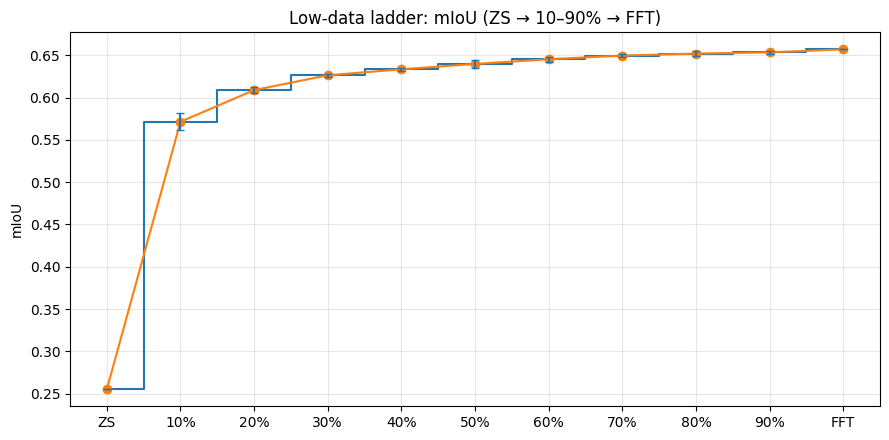

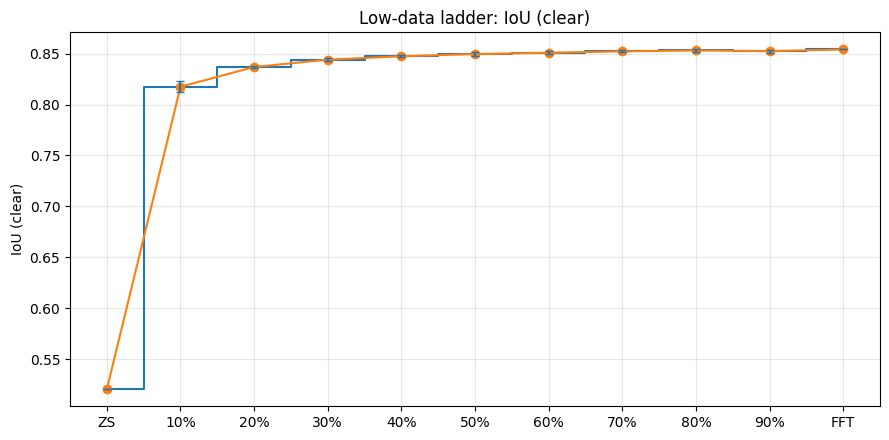

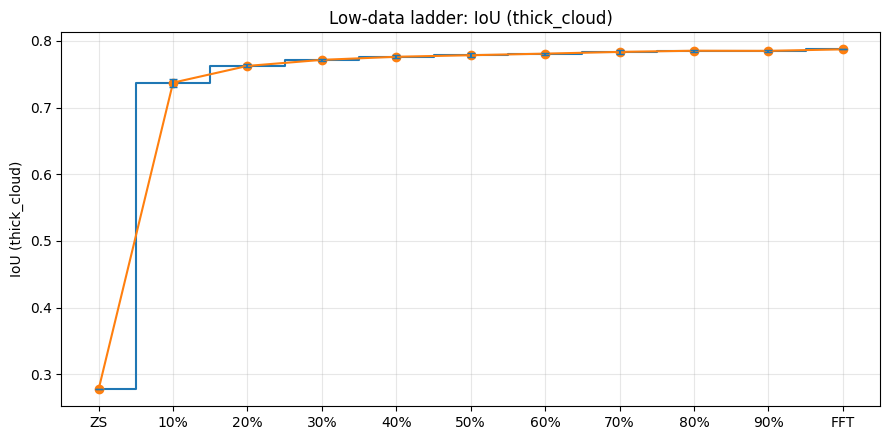

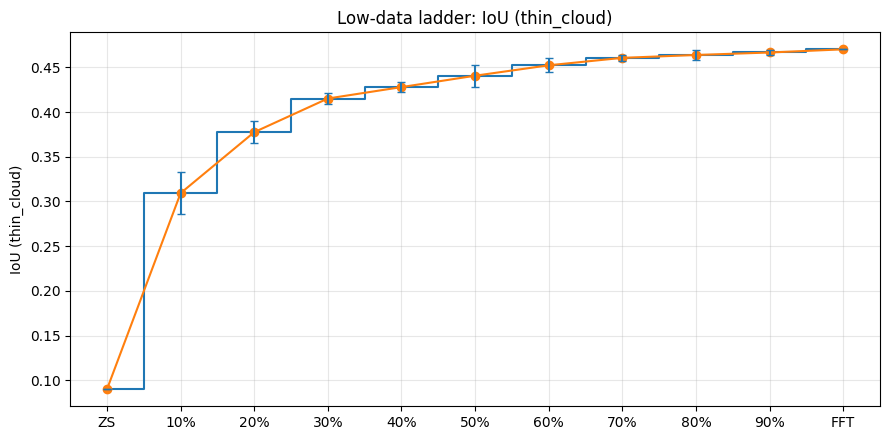

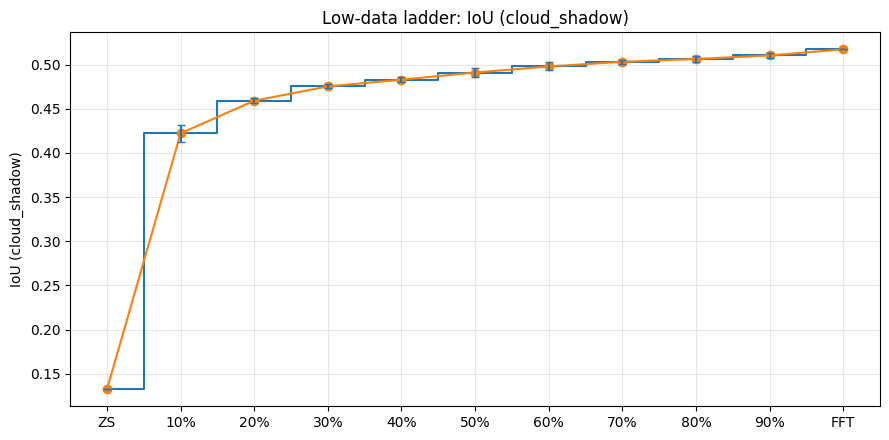

In [22]:
plot_ladder(
    ladder_df,
    metric="miou",
    metric_std="miou_std",
    title="Low-data ladder: mIoU (ZS → 10–90% → FFT)",
    ylabel="mIoU",
)

plot_ladder(
    ladder_df,
    metric="iou_clear",
    metric_std="iou_clear_std",
    title="Low-data ladder: IoU (clear)",
    ylabel="IoU (clear)",
)

plot_ladder(
    ladder_df,
    metric="iou_thick_cloud",
    metric_std="iou_thick_cloud_std",
    title="Low-data ladder: IoU (thick_cloud)",
    ylabel="IoU (thick_cloud)",
)

plot_ladder(
    ladder_df,
    metric="iou_thin_cloud",
    metric_std="iou_thin_cloud_std",
    title="Low-data ladder: IoU (thin_cloud)",
    ylabel="IoU (thin_cloud)",
)

plot_ladder(
    ladder_df,
    metric="iou_cloud_shadow",
    metric_std="iou_cloud_shadow_std",
    title="Low-data ladder: IoU (cloud_shadow)",
    ylabel="IoU (cloud_shadow)",
)


In [23]:
ladder_no_zs = ladder_df[ladder_df["x_label"] != "ZS"].copy()
ladder_no_zs["x"] = np.arange(len(ladder_no_zs))

display(ladder_no_zs[["x_label","miou","miou_std"]])


,x_label,miou,miou_std
1,10%,0.571587,0.010149
2,20%,0.609012,0.004018
3,30%,0.626551,0.001565
4,40%,0.633635,0.002077
5,50%,0.639977,0.005174
6,60%,0.645529,0.003232
7,70%,0.649903,0.001938
8,80%,0.652187,0.002642
9,90%,0.653655,0.002130
10,FFT,0.657245,0.000000


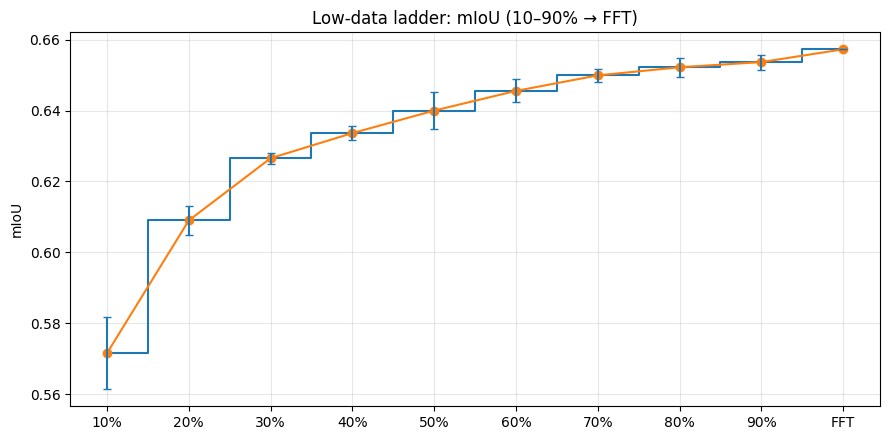

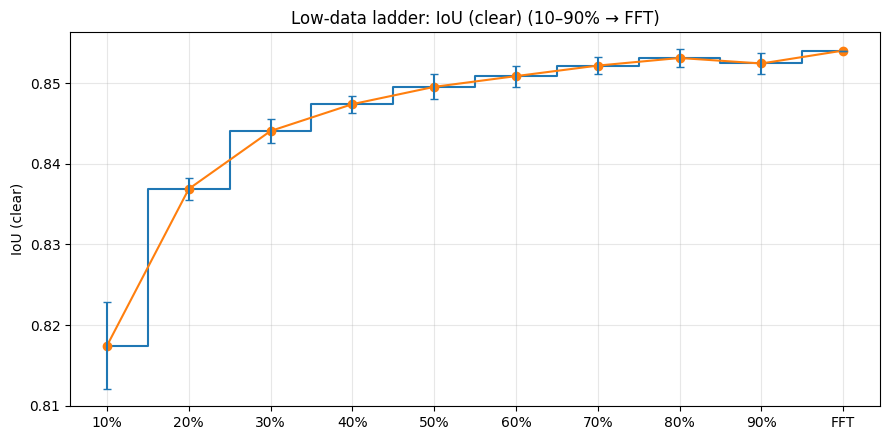

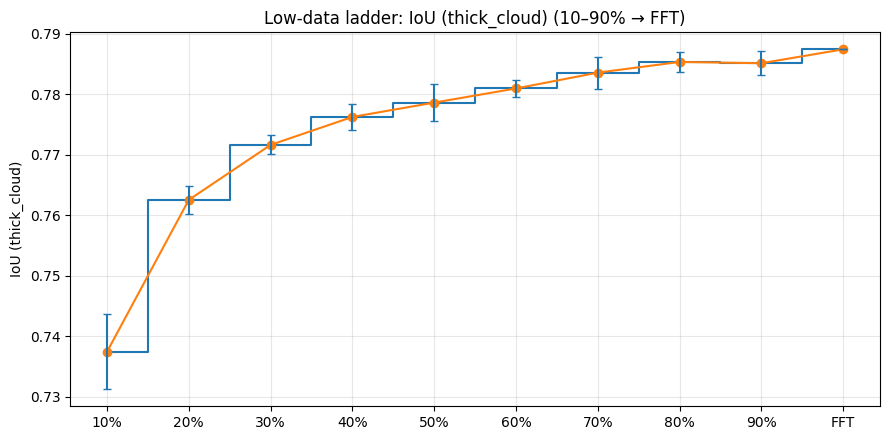

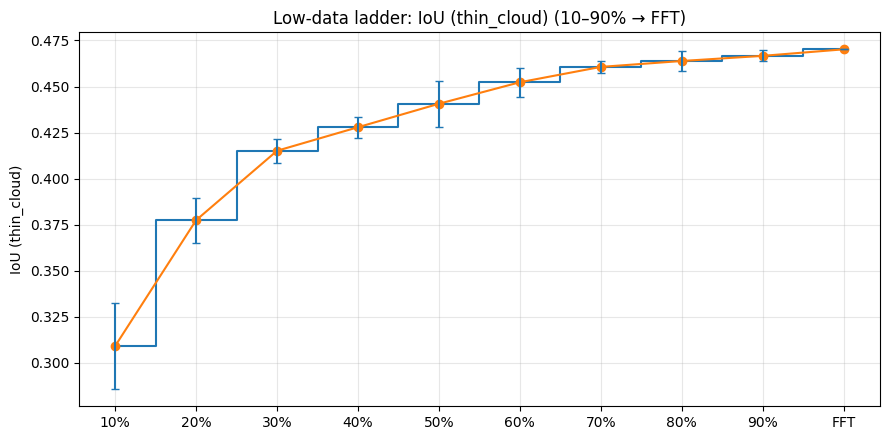

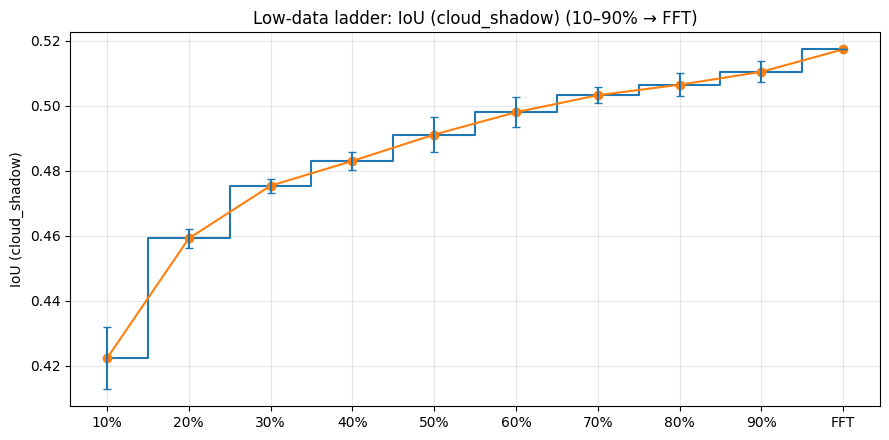

In [24]:
plot_ladder(
    ladder_no_zs,
    metric="miou",
    metric_std="miou_std",
    title="Low-data ladder: mIoU (10–90% → FFT)",
    ylabel="mIoU",
)

plot_ladder(
    ladder_no_zs,
    metric="iou_clear",
    metric_std="iou_clear_std",
    title="Low-data ladder: IoU (clear) (10–90% → FFT)",
    ylabel="IoU (clear)",
)

plot_ladder(
    ladder_no_zs,
    metric="iou_thick_cloud",
    metric_std="iou_thick_cloud_std",
    title="Low-data ladder: IoU (thick_cloud) (10–90% → FFT)",
    ylabel="IoU (thick_cloud)",
)

plot_ladder(
    ladder_no_zs,
    metric="iou_thin_cloud",
    metric_std="iou_thin_cloud_std",
    title="Low-data ladder: IoU (thin_cloud) (10–90% → FFT)",
    ylabel="IoU (thin_cloud)",
)

plot_ladder(
    ladder_no_zs,
    metric="iou_cloud_shadow",
    metric_std="iou_cloud_shadow_std",
    title="Low-data ladder: IoU (cloud_shadow) (10–90% → FFT)",
    ylabel="IoU (cloud_shadow)",
)
